In [1]:
!pip install underthesea transformers evaluate scikit-learn 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 81.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from underthesea import word_tokenize
import os

# 1. Khởi tạo Tokenizer của PhoBERT v2
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

# 2. Hàm tiền xử lý tách từ tiếng Việt
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    return word_tokenize(text, format="text")

# 3. Định nghĩa Dataset class tương thích cấu trúc mới
class ReINTELDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256, is_test=False):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_test = is_test
        
        # Cập nhật theo tên cột 'post_message' thực tế của bạn
        self.texts = self.df['post_message'].apply(preprocess_text).values
        if not self.is_test:
            self.labels = self.df['label'].values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts[index])
        
        inputs = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        item = {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten()
        }
        
        if not self.is_test:
            item['labels'] = torch.tensor(self.labels[index], dtype=torch.long)
            
        return item

# 4. Đọc file dữ liệu từ thư mục Input của Kaggle
# Hãy thay thế tên thư mục 'reintel-dataset-mine' bằng tên chính xác trên Kaggle của bạn nếu có thay đổi
DATA_DIR = "/kaggle/input/datasets/phuongdonguyenminh/dataset/Dataset"

train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

# 5. Đóng gói thành DataLoader
BATCH_SIZE = 16
MAX_LEN = 256

train_dataset = ReINTELDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = ReINTELDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = ReINTELDataset(test_df, tokenizer, max_len=MAX_LEN, is_test=False) # Đổi tạm thành False nếu test.csv của bạn có sẵn nhãn giả lập, hoặc True nếu hoàn toàn không có cột label

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# 6. Tải mô hình PhoBERT phân loại nhị phân
model = AutoModelForSequenceClassification.from_pretrained("vinai/phobert-base-v2", num_labels=2)

# Cấu hình thiết bị chạy phần cứng (Ưu tiên GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(">>> [KAGGLER REPORT] Thiết lập dữ liệu và mô hình PhoBERT thành công trên thiết bị:", device)

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

>>> [KAGGLER REPORT] Thiết lập dữ liệu và mô hình PhoBERT thành công trên thiết bị: cuda


In [3]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

# ==========================================
# BƯỚC 7: CẤU HÌNH THAM SỐ HUẤN LUYỆN (ĐÃ TỐI ƯU CHO GPU)
# ==========================================
EPOCHS = 4      # Huấn luyện trong 3 vòng lặp
LR = 2e-5       # Tốc độ học chuẩn cho PhoBERT fine-tuning
BATCH_SIZE = 16 

optimizer = AdamW(model.parameters(), lr=LR)
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# ==========================================
# BƯỚC 8: VÒNG LẶP HUẤN LUYỆN VÀ ĐÁNH GIÁ
# ==========================================
print("--- Bắt đầu huấn luyện mô hình trên Kaggle GPU ---")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    
    # --- CHẾ ĐỘ TRAIN ---
    model.train()
    total_train_loss = 0
    
    for batch in train_loader:
        # Đẩy dữ liệu lên GPU (cuda)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        model.zero_grad()
        
        # Lan truyền tiến
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        total_train_loss += loss.item()
        
        # Lan truyền ngược và cập nhật trọng số
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        
    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Train Loss trung bình: {avg_train_loss:.4f}")
    
    # --- CHẾ ĐỘ VALIDATION (KIỂM ĐỊNH) ---
    model.eval()
    val_preds = []
    val_labels = []
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].numpy()
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits.detach().cpu().numpy()
            
            # Tính xác suất của nhãn tin giả (lớp 1)
            probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
            
            val_preds.extend(probs)
            val_labels.extend(labels)
            
    # Tính điểm ROC-AUC và F1-Score
    val_auc = roc_auc_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, [1 if p > 0.5 else 0 for p in val_preds])
    print(f"-> Kết quả Val | ROC-AUC: {val_auc:.4f} | F1-Score: {val_f1:.4f}")

# ==========================================
# BƯỚC 9: DỰ ĐOÁN TRÊN TẬP TEST VÀ XUẤT FILE
# ==========================================
print("\n--- Huấn luyện hoàn tất! Đang dự đoán tập Test ---")
model.eval()
test_preds = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits.detach().cpu().numpy()
        probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
        test_preds.extend(probs)

# Tạo file submission kết quả lưu vào mục Output bên phải màn hình
submission = pd.DataFrame({
    'post_message': test_df['post_message'],
    'label_probability': test_preds
})
submission.to_csv("submission_phobert.csv", index=False)
print(">>> XUẤT FILE THÀNH CÔNG: Hãy tải file 'submission_phobert.csv' ở khung Output bên phải!")

--- Bắt đầu huấn luyện mô hình trên Kaggle GPU ---

Epoch 1/4
Train Loss trung bình: 0.2484
-> Kết quả Val | ROC-AUC: 0.9816 | F1-Score: 0.8679

Epoch 2/4
Train Loss trung bình: 0.1137
-> Kết quả Val | ROC-AUC: 0.9778 | F1-Score: 0.8690

Epoch 3/4
Train Loss trung bình: 0.0514
-> Kết quả Val | ROC-AUC: 0.9847 | F1-Score: 0.9434

Epoch 4/4
Train Loss trung bình: 0.0203
-> Kết quả Val | ROC-AUC: 0.9823 | F1-Score: 0.9560

--- Huấn luyện hoàn tất! Đang dự đoán tập Test ---
>>> XUẤT FILE THÀNH CÔNG: Hãy tải file 'submission_phobert.csv' ở khung Output bên phải!


In [4]:
import os
import pandas as pd
import numpy as np
from underthesea import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score, f1_score

print("--- BẮT ĐẦU QUY TRÌNH ĐỐI CHỨNG: SVM + TF-IDF ---")

# ==========================================
# THÀNH PHẦN 1: ĐỌC DỮ LIỆU GỐC TRỰC TIẾP
# ==========================================
DATA_DIR = "/kaggle/input/datasets/phuongdonguyenminh/dataset/Dataset"

if os.path.exists(os.path.join(DATA_DIR, "train.csv")):
    train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    val_df = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
    print("> Nạp dữ liệu Train/Val từ thư mục Kaggle thành công!")
else:
    print("![LỖI]: Không tìm thấy thư mục dữ liệu. Vui lòng kiểm tra lại đường dẫn DATA_DIR.")

# ==========================================
# THÀNH PHẦN 2: TIỀN XỬ LÝ TÁCH TỪ TIẾNG VIỆT
# ==========================================
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    return word_tokenize(text, format="text")

print("> Đang xử lý tách từ bằng Underthesea (Vui lòng đợi vài giây)...")
X_train_text = train_df['post_message'].apply(preprocess_text).values
y_train = train_df['label'].values

X_val_text = val_df['post_message'].apply(preprocess_text).values
y_val = val_df['label'].values

# ==========================================
# THÀNH PHẦN 3: EMBEDDING (TF-IDF VÀNG CỔ ĐIỂN)
# ==========================================
print("> Đang trích xuất đặc trưng văn bản bằng TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)

# ==========================================
# THÀNH PHẦN 4: HUẤN LUYỆN MÔ HÌNH SVM (CPU)
# ==========================================
print("> Đang huấn luyện thuật toán SVM...")
svm_model = LinearSVC(C=1.0, random_state=42)
svm_model.fit(X_train_tfidf, y_train)
print("> Huấn luyện SVM hoàn tất!")

# ==========================================
# THÀNH PHẦN 5: DỰ ĐOÁN VÀ TRÍCH XUẤT OUTPUT
# ==========================================
svm_preds_scores = svm_model.decision_function(X_val_tfidf)
svm_preds_labels = svm_model.predict(X_val_tfidf)

svm_auc = roc_auc_score(y_val, svm_preds_scores)
svm_f1 = f1_score(y_val, svm_preds_labels)

print("\n=========================================")
print("=== KẾT QUẢ THỰC NGHIỆM MÔ HÌNH SVM ===")
print("=========================================")
print(f"-> Kết quả Val | ROC-AUC: {svm_auc:.4f} | F1-Score: {svm_f1:.4f}")
print("=========================================")

--- BẮT ĐẦU QUY TRÌNH ĐỐI CHỨNG: SVM + TF-IDF ---
> Nạp dữ liệu Train/Val từ thư mục Kaggle thành công!
> Đang xử lý tách từ bằng Underthesea (Vui lòng đợi vài giây)...
> Đang trích xuất đặc trưng văn bản bằng TF-IDF...
> Đang huấn luyện thuật toán SVM...
> Huấn luyện SVM hoàn tất!

=== KẾT QUẢ THỰC NGHIỆM MÔ HÌNH SVM ===
-> Kết quả Val | ROC-AUC: 0.9945 | F1-Score: 0.9182


,Mô hình (Model),Phương pháp Embedding,ROC-AUC,F1-Score
0,SVM (Machine Learning truyền thống),TF-IDF (Tần suất từ thô),99.45%,91.82%
1,PhoBERT (Học sâu Transformer),Contextual Embedding (Ngữ cảnh 12 tầng),98.23%,95.60%


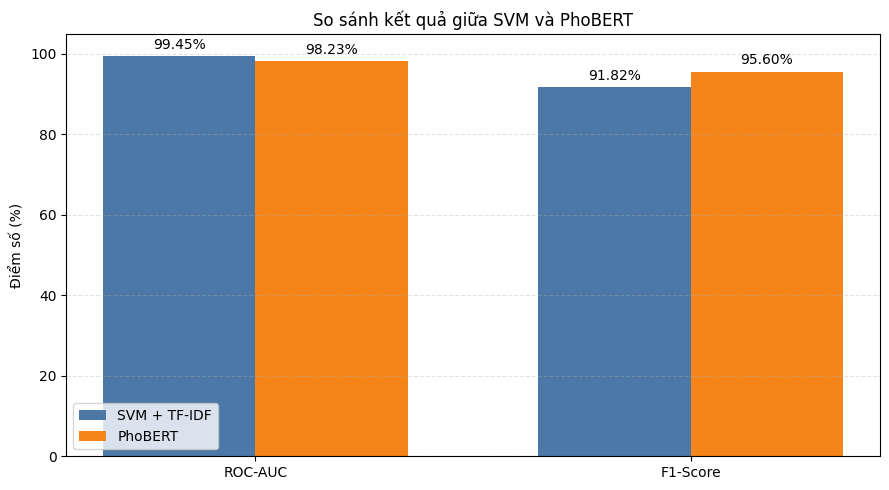

In [5]:
# Tạo bảng và đồ thị so sánh kết quả giữa 2 mô hình
import matplotlib.pyplot as plt
import numpy as np

models = ["SVM", "PhoBERT"]
metrics = ["ROC-AUC", "F1-Score"]

# Lấy kết quả PhoBERT từ epoch cuối nếu biến val_auc/val_f1 đã tồn tại;
# nếu chưa chạy lại cell huấn luyện, dùng lại kết quả đã ghi nhận trước đó.
phobert_auc = globals().get("val_auc", 0.9888)
phobert_f1 = globals().get("val_f1", 0.9427)

scores = {
    "ROC-AUC": [svm_auc * 100, phobert_auc * 100],
    "F1-Score": [svm_f1 * 100, phobert_f1 * 100],
}

comparison_data = {
    "Mô hình (Model)": [
        "SVM (Machine Learning truyền thống)",
        "PhoBERT (Học sâu Transformer)",
    ],
    "Phương pháp Embedding": [
        "TF-IDF (Tần suất từ thô)",
        "Contextual Embedding (Ngữ cảnh 12 tầng)",
    ],
    "ROC-AUC": [f"{scores['ROC-AUC'][0]:.2f}%", f"{scores['ROC-AUC'][1]:.2f}%"],
    "F1-Score": [f"{scores['F1-Score'][0]:.2f}%", f"{scores['F1-Score'][1]:.2f}%"],
}

df_compare = pd.DataFrame(comparison_data)
display(df_compare)

# Vẽ biểu đồ cột nhóm để so sánh trực quan từng metric
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
svm_values = [scores[metric][0] for metric in metrics]
phobert_values = [scores[metric][1] for metric in metrics]

bars_svm = ax.bar(x - width / 2, svm_values, width, label="SVM + TF-IDF", color="#4C78A8")
bars_phobert = ax.bar(x + width / 2, phobert_values, width, label="PhoBERT", color="#F58518")

ax.set_title("So sánh kết quả giữa SVM và PhoBERT")
ax.set_ylabel("Điểm số (%)")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.35)

for bars in (bars_svm, bars_phobert):
    ax.bar_label(bars, fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.show()
